# Test 1 APCEMM PCE Creation

In [1]:
# APCEMM Application of PCE
import numpy as np
import scipy as sc
import totalOrderMultiIndexSet
from numpy.polynomial.hermite_e import HermiteE
from matplotlib.lines import Line2D
from matplotlib import pyplot as plt

plt.rcParams["figure.figsize"] = (10, 6)
import tqdm
import time

In [2]:
### PCE CREATION FUNCTION LIBRARY ###

def PCE():
    
    print("Started!")
    print("--- %s minutes elapsed ---" % round(time.time()/60 - start_time/60,2))
    
    c, alpha_set = compute_c()
    multiindices = alpha_set.shape[0]
    
    print("Got c and alpha!")

    He_array = np.zeros((multiindices, mc_runs))
    u_evals = np.ones(timesteps)
    
    print("Started MC runs!")

    comparison_samples_matrix = get_samples_matrix_online(mc_runs)

    for i in tqdm.tqdm(range(mc_runs)): # for each MC run
        u_evals = np.vstack((u_evals, solve_u(comparison_samples_matrix)))
        
        for j in range(multiindices): # for each coefficient
            current_alpha = alpha_set[j, :] # look at one row at a time for all alpha describing a single coefficient
            samples_matrix_He = comparison_samples_matrix[i, :]
            He_array[j, i] = compute_He(samples_matrix_He, current_alpha)

    # Get rid of first row of ones
    true_output = u_evals[1:,:]

    # Solve for the Least Squares solution
    predicted_output = c.T @ He_array
    
    print("--- %s minutes elapsed ---" % round(time.time()/60 - start_time/60,2))
    
    return predicted_output.T, true_output, c, alpha_set

def compute_c():
    
    c_samples_matrix = get_samples_matrix_offline(training_runs)
    alpha_set = get_alpha_set()
    c_multiindices = alpha_set.shape[0]

    V = np.zeros((training_runs, c_multiindices)) # Vandermonde Matrix: Timesteps x Degree of Polynomial

    for i in tqdm.tqdm(range(training_runs)):
        for j in range(c_multiindices):
            current_alpha = alpha_set[j, :]
            c_samples_matrix_He = c_samples_matrix[i, :]
            V[i, j] = compute_He(c_samples_matrix_He, current_alpha) / np.sqrt(np.product(sc.special.factorial(current_alpha)))

    f = solve_u(c_samples_matrix) # f should be same dimension as V (Training_runs x Degree of Polynomial)
    
    c, residuals, rank, singular_values = np.linalg.lstsq(V.T @ V, V.T @ f)
    
    return c, alpha_set

def func_eval_offline(timesteps, samples_matrix):
    training_samples_matrix_offline_OUTPUTS = training_samples_matrix_offline[:,:,1]
    return training_samples_matrix_offline_OUTPUTS

def dummy_func_eval_online(timesteps, samples_array):

    true_output = np.zeros_like(samples_array)
    for t in range(0, timesteps):
        true_output[:,t] = samples_array[:,t] + (np.sin(2*np.pi*(t+1)/timesteps))
    
    return true_output

def get_samples_matrix_offline(training_runs):
    training_samples_matrix_offline_INPUTS = training_samples_matrix_offline[:,:,0]
    return training_samples_matrix_offline_INPUTS
    

def get_samples_matrix_online(runs):
    return np.random.normal(mean_Y, sigma_Y, size = (runs, timesteps)) # was 0,1

def get_alpha_set():
    return totalOrderMultiIndexSet.totalOrderMultiIndices(poly_dim, max_deg)

def compute_He(Z, alpha):
    res = 1
    for alpha_i, z_i in zip(alpha, Z):
        res = res * HermiteE.basis(deg = alpha_i)(z_i)
    return res

def solve_u(samples_matrix):
    
    u_sol = func_eval_offline(timesteps, samples_matrix) #NOT SURE
    return u_sol

#-----------------------------------------------------------------------------------
### POST-PCE CREATION VALIDATION ###
def validate_u(samples_matrix,index):
    validation_matrix_OUTPUTS = validation_samples_matrix_offline[index,:,1] # TRUE APCEMM SOLUTIONS [Integrated VOD]
    return validation_matrix_OUTPUTS

def validate_PCE(samples_matrix, c, alpha_set):
    multiindices = alpha_set.shape[0]
    He_array = np.zeros((multiindices, validation_runs))
    u_evals = np.ones(timesteps)

    for i in tqdm.tqdm(range(validation_runs)): # for each MC run
        u_evals = np.vstack((u_evals, validate_u(samples_matrix,i)))
        
        for j in range(multiindices): # for each coefficient
            current_alpha = alpha_set[j, :] # look at one row at a time for all alpha describing a single coefficient
            samples_matrix_He = samples_matrix[i, :]
            He_array[j, i] = compute_He(samples_matrix_He, current_alpha)

    # Get rid of first row of ones
    true_output = u_evals[1:,:]

    # Solve for the Least Squares solution
    predicted_output = (c.T @ He_array).T

    return predicted_output, true_output

### Define Constants and PCE Parameters

In [3]:
# Define constants
training_runs = 10 # Number of APCEMM runs for training
timesteps = 73 # Number of samples per APCEMM run (this is the number of timesteps per run) # 20 hours
max_deg = 2 # Maximum value of sum of degrees across the number of uncertain variables (AKA sum of each row of alpha_set must be less than or equal to the max_deg)
poly_dim = 1 # Number of random variables
mc_runs = 1 # Number of PCE runs
training_samples_matrix_offline = np.load('/home/chinahg/GCresearch/contrailuncertainty/PCE/APCEMM_training_sets/test_1/training_sample_matrix.npy') # Import APCEMM training data

#FOR TESTING
mean_Y = 0
sigma_Y = 0.5 #squared value?

### Create PCE and Record Predicted Outputs and Coefficients

In [4]:
start_time = time.time()

# Call PCE function
predicted_output, training_output, coefficients, alpha = PCE()

Started!
--- 0.0 minutes elapsed ---


100%|██████████| 10/10 [00:00<00:00, 35.28it/s]
/tmp/ipykernel_421203/3862491449.py:54: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  c, residuals, rank, singular_values = np.linalg.lstsq(V.T @ V, V.T @ f)


Got c and alpha!
Started MC runs!


100%|██████████| 1/1 [00:00<00:00, 2361.66it/s]

--- 0.01 minutes elapsed ---


### Plot PCE Solution vs Training Data

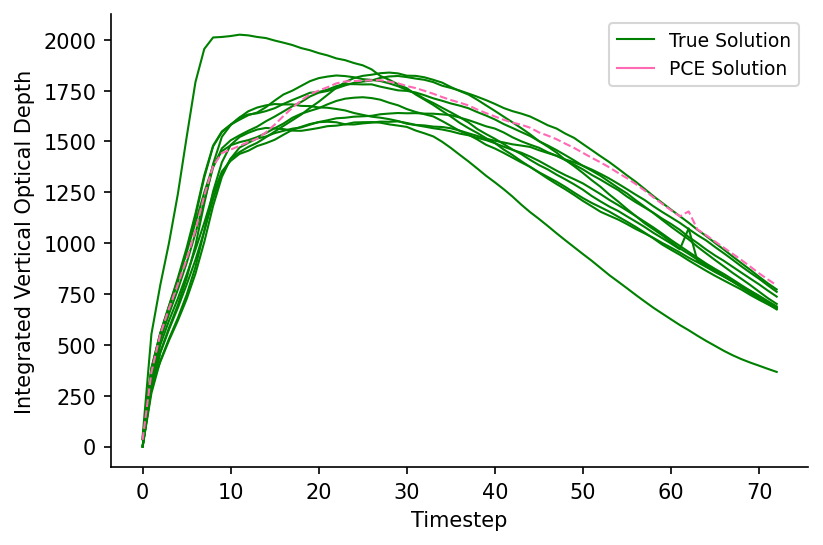

In [5]:
lw = 1
fig, ax = plt.subplots(dpi = 150)
for idx in range(training_runs):
    ax.plot(list(range(0,timesteps)), training_output[idx, :], label = "True", color = "green", lw = lw)
for idx in range(mc_runs):    
    ax.plot(list(range(0,timesteps)), predicted_output[idx, :], label = "PCE", color = "hotpink", ls = "dashed", lw = lw)
    
ax.set_xlabel(xlabel = r"Timestep")
ax.set_ylabel(ylabel = r"Integrated Vertical Optical Depth")

custom_lines = [Line2D([0], [0], color="green", lw=1), Line2D([0], [0], color="hotpink", lw=1)] # 

ax.legend(custom_lines, ['True Solution', 'PCE Solution'], fontsize = 9)

ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

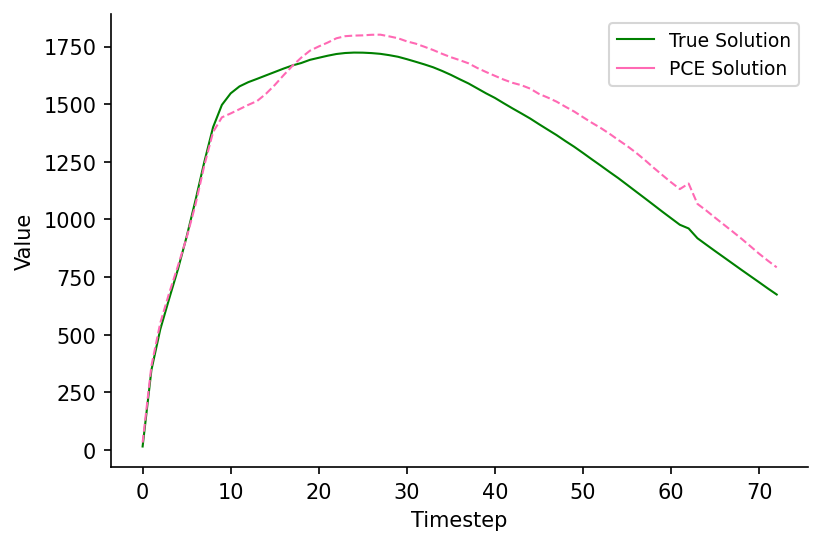

In [6]:
lw = 1
fig, ax = plt.subplots(dpi = 150)

ax.plot(list(range(0,timesteps)), training_output.mean(axis=0), label = "True", color = "green", lw = lw)
ax.plot(list(range(0,timesteps)), predicted_output.mean(axis=0), label = "PCE", color = "hotpink", ls = "dashed", lw = lw)

# ax.set_xlim(0,1)
ax.set_xlabel(xlabel = r"Timestep")
ax.set_ylabel(ylabel = r"Value")

custom_lines = [Line2D([0], [0], color="green", lw=1), Line2D([0], [0], color="hotpink", lw=1)] # 

ax.legend(custom_lines, ['True Solution', 'PCE Solution'], fontsize = 9)

ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

### Validation of PCE created surrogate

In [7]:
validation_runs = 2 # Number of novel APCEMM input arrays to compare against the PCE
validation_samples_matrix_offline = np.load('/home/chinahg/GCresearch/contrailuncertainty/PCE/APCEMM_training_sets/test_1/validation_sample_matrix.npy') # Import APCEMM training data
validation_matrix_INPUTS = validation_samples_matrix_offline[:,:,0] # APCEMM inputs that were not trained on, and we also have the True solution for

In [8]:
v_predicted_output, v_true_output = validate_PCE(validation_matrix_INPUTS, coefficients, alpha)

100%|██████████| 2/2 [00:00<00:00, 2860.08it/s]


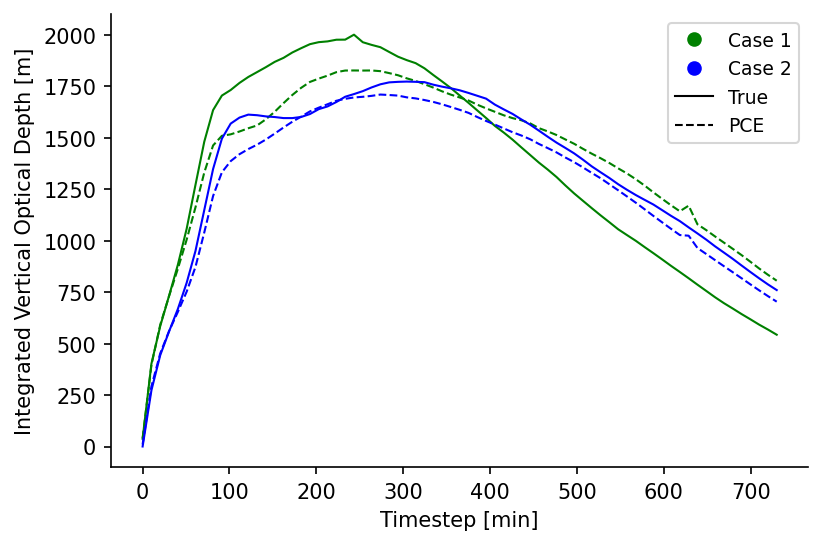

In [9]:
lw = 1
fig, ax = plt.subplots(dpi = 150)

colors = ['green', 'blue', 'red', 'orange']
line_styles = ['-', '--', '-.', ':']
time_min = timesteps*10

for idx in range(validation_runs):
    ax.plot(list(np.linspace(0, time_min, timesteps)), v_true_output[idx, :], label = f"Case {idx+1}", color = colors[idx % len(colors)], lw = lw, ls = line_styles[0])
    ax.plot(list(np.linspace(0, time_min, timesteps)), v_predicted_output[idx, :], label = f"PCE", color = colors[idx % len(colors)], lw = lw, ls = line_styles[1])

ax.set_xlabel(xlabel = r"Timestep [min]")
ax.set_ylabel(ylabel = r"Integrated Vertical Optical Depth [m]")

custom_lines = [Line2D([0], [0], color=color, lw=0, marker='o') for color in colors[:validation_runs]] + \
               [Line2D([0], [0], color='black', lw=1, ls='-'), Line2D([0], [0], color='black', lw=1, ls=line_styles[1])]

ax.legend(custom_lines, [f"Case {i+1}" for i in range(validation_runs)] + ['True', 'PCE'], fontsize = 9)

ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

In [11]:
# Simulated coefficients: rows represent different basis terms, columns represent timesteps
pce_coeffs = coefficients

# Number of uncertain variables
num_variables = 3
num_basis = pce_coeffs.shape[0]  # Number of basis terms

# Compute total variance for each timestep (sum of squared coefficients excluding the constant term)
total_variance = np.sum(pce_coeffs[1:, :] ** 2, axis=0)  # Sum across basis terms, excluding the first row

# Dictionary to store total effect sensitivity indices
S_T = {}

# Assuming that each variable's basis functions are in consecutive blocks, 
# we will group basis terms by the uncertain variables they correspond to.
for var_idx in range(num_variables):
    # For each uncertain variable, sum over the basis terms that correspond to that variable.
    # Assuming here that each variable's terms are grouped consecutively in the matrix:
    start_idx = var_idx * (num_basis // num_variables)  # Starting index for this variable's terms
    end_idx = start_idx + (num_basis // num_variables)  # Ending index for this variable's terms
    
    # Sum over all terms that involve this variable (main effect + interactions)
    variance_contribution = np.sum(pce_coeffs[start_idx:end_idx, :] ** 2, axis=0)  # Sum over terms for this variable
    S_T[f"S_T_{var_idx}"] = variance_contribution / total_variance

# Print the total effect sensitivity indices for the first few timesteps
print("Total Effect Sensitivity Indices (S_T) for first few timesteps:")
for key, values in S_T.items():
    print(f"{key}: {values[:5]}")  # Print first 5 timesteps for brevity

Total Effect Sensitivity Indices (S_T) for first few timesteps:
S_T_0: [0.06713671 2.3079234  2.83118282 3.43910296 3.74519243]
S_T_1: [0.79356392 0.99415258 0.98709817 0.9983847  0.99593626]
S_T_2: [0.20643608 0.00584742 0.01290183 0.0016153  0.00406374]


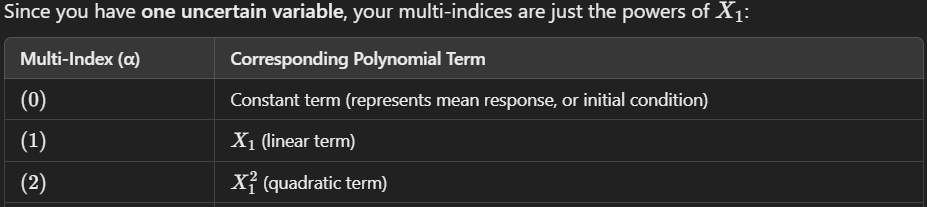

In [12]:
from IPython.display import Image

# Display the image
image_path = '/home/chinahg/GCresearch/contrailuncertainty/PCE/PCE_processing/multi_indices_expl.png'
Image(filename=image_path)